In [ ]:
from matplotlib import pyplot as plt
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
import pandas as pd
from utils import num_params
from config import N_TRAIN, K
from matplotlib.ticker import ScalarFormatter


In [3]:
avg_train_zeroone, avg_test_zeroone, avg_train_MSE, avg_test_MSE = [0.78125,    0.78125,    0.78074998, 0.78074998, 0.88075,    0.88050002, 0.88050002, 0.88050002, 0.88050002, 0.88050002, 0.88050002, 0.88050002,0.88050002, 0.78100002, 0.77600002, 0.77450001, 0.77350003, 0.0135,0.014,      0.01525,    0.00475,    0.00475,    0.002,      0.0        ], [0.79030001, 0.79049999, 0.79030001, 0.79070002, 0.8865,     0.88599998,0.88599998, 0.88599998, 0.88599998, 0.88590002, 0.8858,     0.8858, 0.8858,     0.79119998, 0.78829998, 0.78829998, 0.78780001, 0.1026, 0.1033,     0.1022,     0.077,      0.0764,     0.0603,     0.0529, 0.0488    ], [0.08067238, 0.08056693, 0.08052249, 0.08049908, 0.08993229, 0.08992846, 0.08992764, 0.08992667, 0.08992559, 0.08992438, 0.08992309, 0.08992173, 0.08992035, 0.08007167, 0.079294,   0.07908524, 0.07896276, 0.0059696, 0.00617298, 0.0064407,  0.00446036, 0.00392937, 0.00236464, 0.00169955, 0.00028623], [0.08184607, 0.08207406, 0.08219709, 0.08229001, 0.08999116, 0.09009076, 0.09008916, 0.09008736, 0.09008556, 0.09008205, 0.09007975, 0.09007734, 0.09007471, 0.08047467, 0.07991359, 0.07984303, 0.07982336, 0.02264112, 0.0219935,  0.02188934, 0.01941769, 0.01892305, 0.01675715, 0.01729992,0.01828166,]

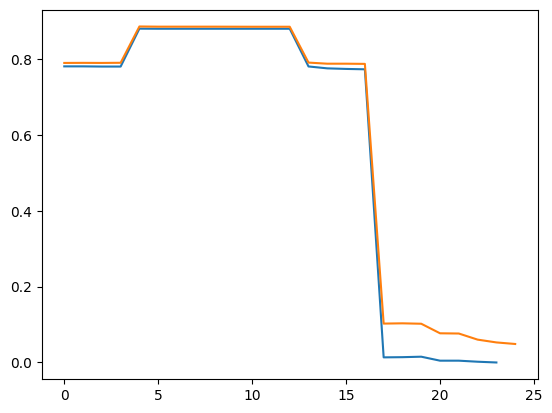

In [7]:
plt.plot(avg_train_zeroone, label="Train")
plt.plot(avg_test_zeroone, label="Test")

In [57]:
sweep_df = pd.read_csv('../results/sweep_results_mse.csv')
sweep_df

,H,train_zeroone,test_zeroone,train_MSE,test_MSE
0,4,0.84145,0.84856,0.085663,0.086258
1,5,0.76090,0.77418,0.078036,0.079306
2,8,0.53715,0.55670,0.057741,0.060967
3,13,0.14605,0.20382,0.024035,0.032483
4,18,0.05480,0.14110,0.014142,0.028184
5,23,0.02790,0.13218,0.009541,0.028003
6,25,0.02300,0.14294,0.008199,0.030559
7,28,0.02105,0.15266,0.007313,0.033159
8,30,0.01880,0.15878,0.006521,0.035051
9,33,0.01700,0.16582,0.005898,0.037008


In [58]:
sweep_df["params"] = num_params(sweep_df["H"])

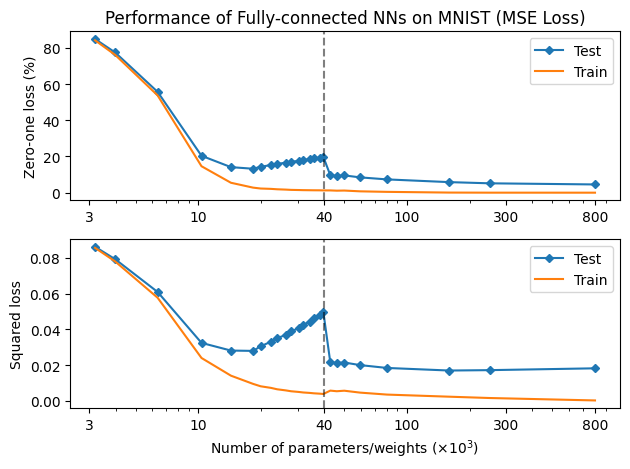

In [64]:
plt.subplot(211)
plt.title("Performance of Fully-connected NNs on MNIST (MSE Loss)")
plt.semilogx(sweep_df['params']/1e3, sweep_df['test_zeroone']*100, marker='D', ms=4, label="Test", color="tab:blue")
plt.semilogx(sweep_df['params']/1e3, sweep_df['train_zeroone']*100, label="Train", color="tab:orange")
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.ticklabel_format(style='plain', axis='x')
ticks = [3, 10, 40, 100, 300, 800]
plt.xticks(ticks)
plt.axvline([N_TRAIN*K/1e3], color='black', linestyle='--', alpha=0.5)
plt.ylabel("Zero-one loss (%)")
plt.legend()
plt.tight_layout()
plt.subplot(212)
plt.semilogx(sweep_df['params']/1e3, sweep_df['test_MSE'], marker='D', ms=4, label="Test", color="tab:blue")
plt.semilogx(sweep_df['params']/1e3, sweep_df['train_MSE'], label="Train", color="tab:orange")
plt.xlabel(r"Number of parameters/weights ($\times10^3$)")
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.ticklabel_format(style='plain', axis='x')
ticks = [3, 10, 40, 100, 300, 800]
plt.xticks(ticks, [str(t) for t in ticks])
plt.axvline([N_TRAIN*K/1e3], color='black', linestyle='--', alpha=0.5)
plt.ylabel("Squared loss")
plt.legend()
plt.tight_layout()
plt.savefig('../plots/full_batch_sweep_mse.jpg')